# Phase 2 — Tabular Merge, Cleaning & EDA

**Group 19 — Multimodal Auth & Product Recommendation System**

Goal: build the tabular table that a model uses to predict **the product a customer would buy
*when visiting our social media sites*** — i.e. at social-visit time, *before* any purchase.
This notebook mirrors `scripts/merge_and_clean.py` and documents the EDA.

### Prediction framing → column roles
Because the prediction happens *before* the purchase, only the **social** features are legitimately
available as inputs; the transaction columns are post-purchase and would **leak** the outcome:

| role | columns |
|---|---|
| identifiers | `customer_id`, `transaction_id` |
| **predictors** (social, known at visit time) | `avg_engagement`, `avg_purchase_interest`, `n_platforms`, `primary_platform`, `dominant_sentiment` |
| **target** | `product_category` |
| **excluded** (post-purchase → leakage) | `purchase_date`, `purchase_amount`, `customer_rating` |

All columns are kept in the CSV for reference/EDA, but **Phase 5 trains on the predictors only.**

### Three design decisions
1. **Join key** — `customer_id_new` (`"A"`+digits) equals `customer_id_legacy` once the `A` is stripped.
2. **Grain** — both tables are one-to-many per customer, so social is *aggregated to one row per
   customer* before joining (a raw row-join would multiply rows).
3. **Join type — INNER.** The task predicts *from* the social profile, so the population is the
   customers who have a social profile **and** purchased. Inner join matches that framing and avoids
   fabricating the predictor features by imputation (which LEFT would force on 33 social-less rows).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import merge_and_clean as mc  # single source of truth for the cleaning logic

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

## 1. Load the raw tables

In [2]:
soc_raw, tx_raw = mc.load_raw()
print("social_profiles:", soc_raw.shape, "| transactions:", tx_raw.shape)
soc_raw.head()

social_profiles: (155, 5) | transactions: (150, 6)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


In [3]:
tx_raw.head()

,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


## 2. The join key — two different ID schemes
`customer_social_profiles.customer_id_new` looks like `A178`; `customer_transactions.customer_id_legacy`
is the integer `178`. Stripping the leading `A` reconciles them (verified: every id matches `^A\d+$`).

In [4]:
assert soc_raw["customer_id_new"].str.fullmatch(r"A\d+").all()
soc_ids = set(soc_raw["customer_id_new"].str[1:].astype(int))
tx_ids = set(tx_raw["customer_id_legacy"])
print("customers in social :", len(soc_ids))
print("customers in tx     :", len(tx_ids))
print("overlap (both)      :", len(soc_ids & tx_ids))
print("tx only (no social) :", len(tx_ids - soc_ids))
print("social only (no tx) :", len(soc_ids - tx_ids))

customers in social : 84
customers in tx     : 75
overlap (both)      : 61
tx only (no social) : 14
social only (no tx) : 23


**Interpretation.** 61 customers appear in both tables. 14 have transactions but no social profile,
23 have a social profile but never purchased. Since the model predicts *from* the social profile, the
14 social-less customers can't be scored meaningfully — the **inner join** keeps exactly the 61
customers present in both, and drops the rest rather than imputing their predictors.

## 3. Cleaning: duplicates, aggregation, grain

- **Exact duplicates only are dropped** (5 identical social rows). Rows that repeat on
  `(customer, platform)` with different readings are **aggregated, not discarded** — they are
  genuine repeated observations, not errors.
- **Social is aggregated to one row per customer**: `avg_engagement`, `avg_purchase_interest` (means),
  `n_platforms` (distinct count), `primary_platform`, `dominant_sentiment` (modes). This is required
  because social is one-to-many per customer; aggregating first is what stops the join from exploding.
- **Transactions**: 10 null `customer_rating` values imputed with the median (kept for completeness
  even though `customer_rating` is an excluded/leaky column); `purchase_date` parsed to datetime.
- **Grain of the final table**: **one row per transaction** (of a social-profile customer). A customer
  with several purchases appears several times; the target is that transaction's `product_category`.

In [5]:
soc_agg = mc.clean_social(soc_raw)
tx = mc.clean_transactions(tx_raw)
merged = mc.merge(tx, soc_agg)
merged.head()

  social: dropped 5 exact duplicate rows -> 150 rows
  social: 19 repeated (customer, platform) readings -> summarised, not dropped
  social: aggregated to 84 unique customers
  transactions: 0 exact duplicate rows
  transactions: imputed 10 null customer_rating with median=3.0 (excluded feature)


,customer_id,transaction_id,avg_engagement,avg_purchase_interest,n_platforms,primary_platform,dominant_sentiment,purchase_date,purchase_amount,customer_rating,product_category
0,151,1001,71.67,2.17,2,Twitter,Neutral,2024-01-01,408,2.3,Sports
1,192,1002,60.00,4.30,1,Instagram,Positive,2024-01-02,332,4.2,Electronics
2,114,1003,87.00,4.80,1,Facebook,Negative,2024-01-03,442,2.1,Electronics
3,160,1005,72.67,2.50,3,Instagram,Neutral,2024-01-05,64,1.3,Clothing
4,120,1006,77.00,2.67,2,Instagram,Positive,2024-01-06,395,1.1,Groceries


## 4. Post-merge validation

In [6]:
mc.validate(tx, soc_agg, merged)


  --- post-merge validation ---
  rows: transactions=150 -> merged=117  (inner join dropped 33 transactions from customers with no social profile)
  remaining nulls: none
  spot-check customer 151: agg={'avg_engagement': 71.67, 'primary_platform': 'Twitter'} == merged={'avg_engagement': 71.67, 'primary_platform': 'Twitter'} -> True
  column roles:
    predictors : ['avg_engagement', 'avg_purchase_interest', 'n_platforms', 'primary_platform', 'dominant_sentiment']
    target     : product_category
    excluded   : ['purchase_date', 'purchase_amount', 'customer_rating']  (post-purchase - not model inputs)

  target (product_category) distribution:
product_category
Sports         28
Electronics    27
Clothing       22
Books          20
Groceries      20


**Interpretation.** The inner join reduces 150 transactions to **117** — the 33 dropped rows belong
to the 14 customers with no social profile, so the reduction is expected, not accidental data loss.
`transaction_id` stays unique, every social feature is populated (no imputed predictors), and there
are no residual nulls.

## 5. Column roles (predictors vs target vs excluded)
Exported from the script so Phase 5 imports the exact same split.

In [7]:
print("predictors:", mc.PREDICTORS)
print("target    :", mc.TARGET)
print("excluded  :", mc.EXCLUDED_LEAKAGE, "(post-purchase - NOT model inputs)")

predictors: ['avg_engagement', 'avg_purchase_interest', 'n_platforms', 'primary_platform', 'dominant_sentiment']
target    : product_category
excluded  : ['purchase_date', 'purchase_amount', 'customer_rating'] (post-purchase - NOT model inputs)


## 6. Summary statistics & variable types

In [8]:
num_cols = ["avg_engagement", "avg_purchase_interest", "n_platforms", "purchase_amount", "customer_rating"]
merged[num_cols].describe().round(2)

,avg_engagement,avg_purchase_interest,n_platforms,purchase_amount,customer_rating
count,117.00,117.00,117.00,117.00,117.00
mean,74.15,3.08,1.60,287.91,3.11
std,12.67,1.04,0.73,120.08,1.20
min,50.00,1.00,1.00,62.00,1.00
25%,66.50,2.67,1.00,183.00,2.10
50%,77.00,3.13,1.00,280.00,3.20
75%,83.00,3.70,2.00,397.00,4.10
max,99.00,4.80,4.00,495.00,5.00


In [9]:
types = pd.DataFrame({"dtype": merged.dtypes.astype(str)})
types["kind"] = np.where(merged.dtypes == "category", "categorical",
                 np.where(merged.dtypes == object, "text/date", "numeric"))
types["role"] = ["predictor" if c in mc.PREDICTORS else "target" if c == mc.TARGET
                 else "excluded" if c in mc.EXCLUDED_LEAKAGE else "id" for c in merged.columns]
types

,dtype,kind,role
customer_id,int64,numeric,id
transaction_id,int64,numeric,id
avg_engagement,float64,numeric,predictor
avg_purchase_interest,float64,numeric,predictor
n_platforms,int64,numeric,predictor
primary_platform,category,categorical,predictor
dominant_sentiment,category,categorical,predictor
purchase_date,datetime64[us],numeric,excluded
purchase_amount,int64,numeric,excluded
customer_rating,float64,numeric,excluded


## 7. Plot 1 — Distributions of the social predictors
The model's actual inputs, so we look at these first.

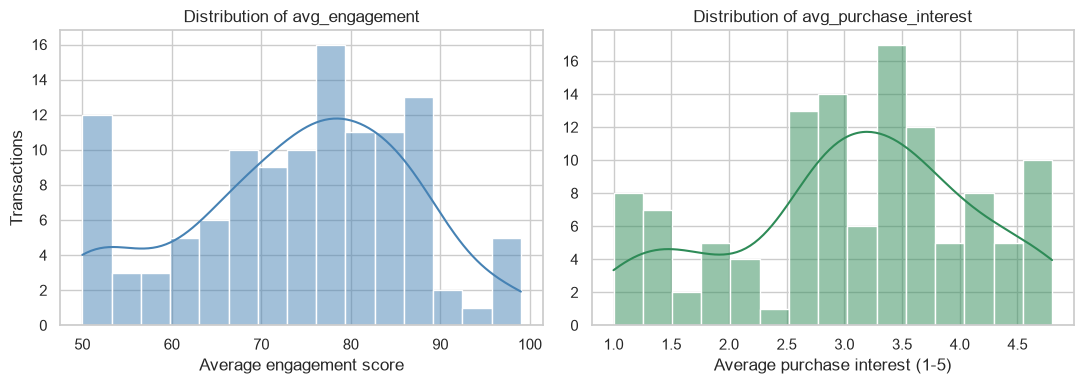

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(merged["avg_engagement"], bins=15, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of avg_engagement")
axes[0].set_xlabel("Average engagement score"); axes[0].set_ylabel("Transactions")
sns.histplot(merged["avg_purchase_interest"], bins=15, kde=True, color="seagreen", ax=axes[1])
axes[1].set_title("Distribution of avg_purchase_interest")
axes[1].set_xlabel("Average purchase interest (1-5)"); axes[1].set_ylabel("")
fig.tight_layout(); fig.savefig(FIG / "01_social_predictor_dist.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.** `avg_engagement` centres around 74 (range 50–99, slight left skew ≈ −0.33) and
`avg_purchase_interest` around 3.1 on the 1–5 scale (skew ≈ −0.32). Both predictors are well spread
rather than degenerate, so they carry usable variation for the model.

## 8. Plot 2 — Outlier check (boxplots)

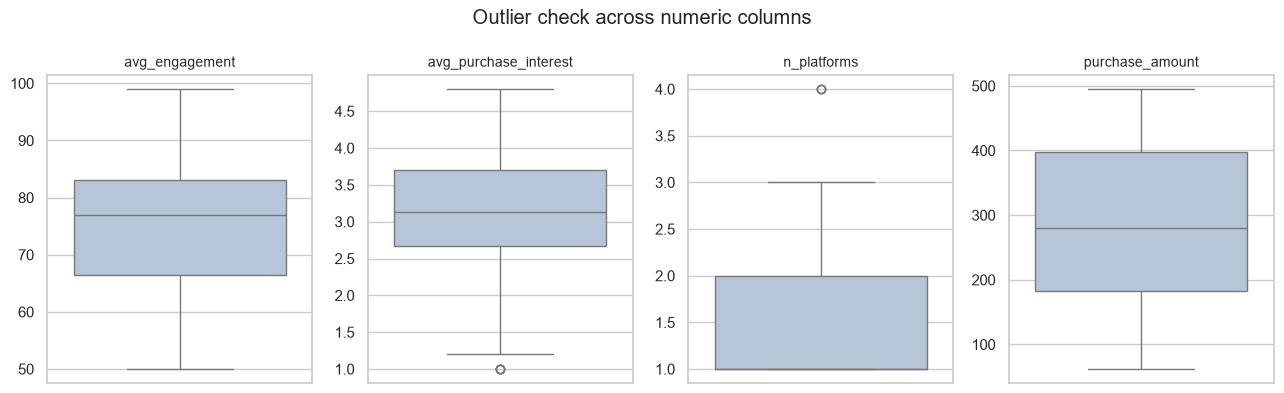

In [11]:
cols = ["avg_engagement", "avg_purchase_interest", "n_platforms", "purchase_amount"]
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, c in zip(axes, cols):
    sns.boxplot(y=merged[c], color="lightsteelblue", ax=ax)
    ax.set_title(c, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Outlier check across numeric columns")
fig.tight_layout(); fig.savefig(FIG / "02_outlier_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.** `avg_engagement` and `purchase_amount` show no IQR outliers. `avg_purchase_interest`
has 4 mild low outliers and `n_platforms` has 3 high outliers — the handful of customers active on 3–4
platforms. None are data errors (all within valid ranges), so they are kept rather than clipped.

## 9. Plot 3 — Correlation heatmap (numeric features)

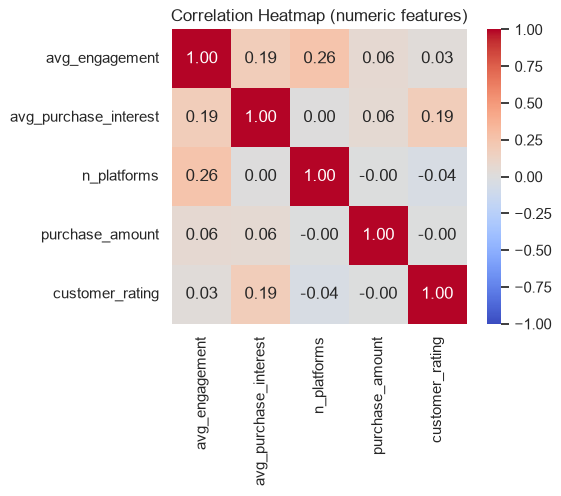

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(merged[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation Heatmap (numeric features)")
fig.tight_layout(); fig.savefig(FIG / "03_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.** The numeric features are close to independent; the only notable link is
`avg_engagement`–`n_platforms` (0.26 — more engaged customers use more platforms). There is no
multicollinearity, and little *linear* signal among the numerics — which points to the **categorical**
social feature `primary_platform` (next plots) as the real predictor.

## 10. Plot 4 — Target balance

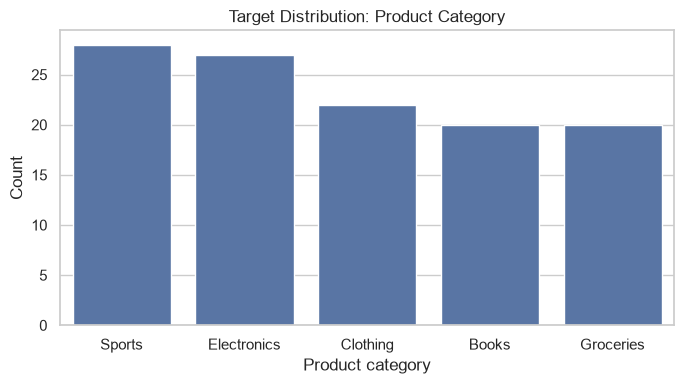

product_category
Sports         28
Electronics    27
Clothing       22
Books          20
Groceries      20
Name: count, dtype: int64

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=merged, x="product_category",
              order=merged["product_category"].value_counts().index, ax=ax)
ax.set_title("Target Distribution: Product Category")
ax.set_xlabel("Product category"); ax.set_ylabel("Count")
fig.tight_layout(); fig.savefig(FIG / "04_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
merged["product_category"].value_counts()

**Interpretation.** The five categories stay balanced after the inner join (20–28 each), so plain
accuracy is a meaningful Phase 5 metric and no class re-balancing is needed.

## 11. Plot 5 — Product category by primary platform  *(key predictive signal)*
Does the social profile actually predict the product? This is the question the whole task hinges on.

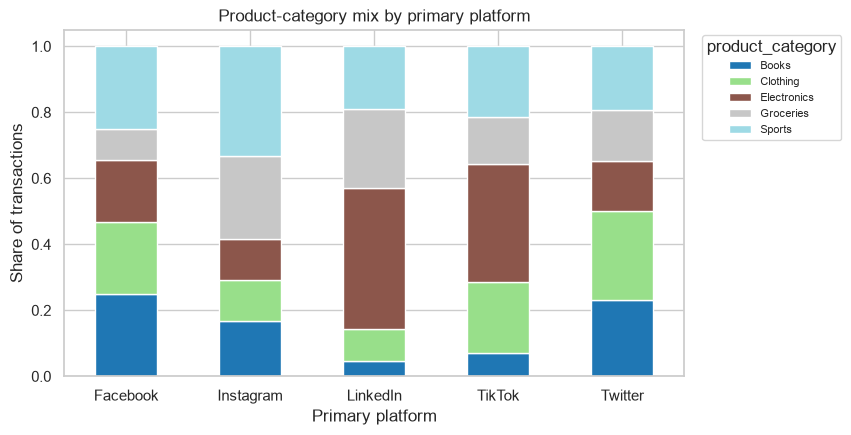

product_category,Books,Clothing,Electronics,Groceries,Sports
primary_platform,,,,,
Facebook,25,22,19,9,25
Instagram,17,12,12,25,33
LinkedIn,5,10,43,24,19
TikTok,7,21,36,14,21
Twitter,23,27,15,15,19


In [14]:
ct = pd.crosstab(merged["primary_platform"], merged["product_category"], normalize="index")
fig, ax = plt.subplots(figsize=(8, 4.5))
ct.plot(kind="bar", stacked=True, colormap="tab20", ax=ax)
ax.set_title("Product-category mix by primary platform")
ax.set_xlabel("Primary platform"); ax.set_ylabel("Share of transactions")
ax.legend(title="product_category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
fig.savefig(FIG / "05_category_by_platform.png", dpi=120, bbox_inches="tight")
plt.show()
(ct.round(2) * 100).astype(int)

**Interpretation — the main finding.** Primary platform clearly shifts the product mix: **LinkedIn
buyers are 43% Electronics and TikTok 36%** (against a ~23% baseline), while **Instagram skews to
Sports (33%) and Groceries (25%)** and Twitter toward Clothing (27%). This is the strongest predictor
in the data and directly supports the task — the social channel a customer engages on *does* carry
information about what they buy, so the Phase 5 model has real signal to learn from.

## 12. Plot 6 — Product category by dominant sentiment  *(for contrast)*

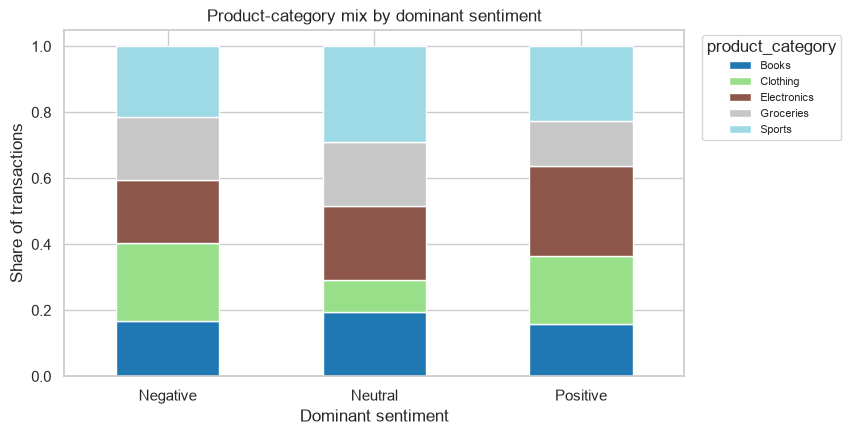

product_category,Books,Clothing,Electronics,Groceries,Sports
dominant_sentiment,,,,,
Negative,17,24,19,19,21
Neutral,19,10,23,19,28
Positive,16,20,27,14,23


In [15]:
ct2 = pd.crosstab(merged["dominant_sentiment"], merged["product_category"], normalize="index")
fig, ax = plt.subplots(figsize=(8, 4.5))
ct2.plot(kind="bar", stacked=True, colormap="tab20", ax=ax)
ax.set_title("Product-category mix by dominant sentiment")
ax.set_xlabel("Dominant sentiment"); ax.set_ylabel("Share of transactions")
ax.legend(title="product_category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
fig.savefig(FIG / "06_category_by_sentiment.png", dpi=120, bbox_inches="tight")
plt.show()
(ct2.round(2) * 100).astype(int)

**Interpretation.** By contrast, `dominant_sentiment` barely moves the product mix — every category
stays around 16–28% across Negative / Neutral / Positive. Sentiment is a weak predictor relative to
platform, useful to know before feature selection in Phase 5.

## 13. Output & takeaways for Phase 5

- `data/processed/merged_dataset.csv` (117 rows) is written by `scripts/merge_and_clean.py`.
- **Train on the predictors only** (`mc.PREDICTORS`); exclude the post-purchase columns to avoid leakage.
- **`primary_platform` is the strongest signal**; `avg_purchase_interest` has modest signal (Electronics
  buyers score highest); engagement and sentiment are weak.
- Weak linear structure + a categorical star feature → a **non-linear / tree model** (random forest,
  XGBoost) is the natural first choice in Phase 5.